# 01 — Data Audit and Exploratory Data Analysis

## Objectives

This notebook will:

1. Verify the dataset's real dimensions and schema.
2. Investigate possible Excel export truncation.
3. Measure timestamp and city coverage.
4. Detect missing values, duplicates, invalid values, and temporal gaps.
5. Determine whether seasonal analysis is defensible.
6. examine provisional AQI class balance.
7. Recommend Dhaka plus 2–4 cities for the project.

No preprocessing or modeling is performed in this notebook.

In [21]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Environment and Project Setup

This section prepares the Google Colab environment for the audit.

It:

- Mounts Google Drive so the raw dataset and generated outputs remain available after the Colab runtime ends.
- Clones the GitHub repository if it is not already present.
- Pulls the newest version of the selected Git branch.
- Creates separate folders for raw data, audit outputs, and figures.
- Imports the libraries required for data analysis and visualization.
- Sets a fixed random seed to make sampling and plots reproducible.

No dataset is modified during this step.

In [22]:
from pathlib import Path
from IPython.display import display

import hashlib
import json
import os
import re
import unicodedata
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

WORKING_DIR = Path("/content")
os.chdir(WORKING_DIR)

STORAGE_ROOT = Path("/content/drive/MyDrive/CSE437_air_quality_group_18")
RAW_DIR = STORAGE_ROOT / "raw"
PROCESSED_DIR = STORAGE_ROOT / "processed"
AUDIT_DIR = PROCESSED_DIR / "notebook_01_audit"
FIGURES_DIR = STORAGE_ROOT / "figures" / "notebook_01"

RAW_DIR.mkdir(parents=True, exist_ok=True)
AUDIT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Working directory:", WORKING_DIR)
print("Raw data:", RAW_DIR)
print("Audit outputs:", AUDIT_DIR)
print("Figures:", FIGURES_DIR)

Working directory: /content
Raw data: /content/drive/MyDrive/CSE437_air_quality_group_18/raw
Audit outputs: /content/drive/MyDrive/CSE437_air_quality_group_18/processed/notebook_01_audit
Figures: /content/drive/MyDrive/CSE437_air_quality_group_18/figures/notebook_01


## 2. Raw Dataset Identification and Integrity Check

This section selects `AQI Bangladesh.csv` as the main hourly air-quality dataset.

The filename is specified explicitly because the raw-data folder also contains `cities.csv`. The code verifies that the main file exists and calculates its file size and SHA-256 checksum for reproducibility.

In [23]:
RAW_FILE_NAME = "AQI Bangladesh.csv"

if RAW_FILE_NAME:
    RAW_FILE = RAW_DIR / RAW_FILE_NAME

    if not RAW_FILE.is_file():
        raise FileNotFoundError(f"File not found: {RAW_FILE}")
else:
    csv_files = sorted(RAW_DIR.glob("*.csv"))

    if len(csv_files) == 0:
        raise FileNotFoundError(f"No CSV file found in {RAW_DIR}")

    if len(csv_files) > 1:
        print("Multiple CSV files found:")

        for file in csv_files:
            print("-", file.name)

        raise ValueError("Set RAW_FILE_NAME to the correct source filename.")

    RAW_FILE = csv_files[0]

def calculate_sha256(file_path):
    digest = hashlib.sha256()

    with file_path.open("rb") as file:
        for chunk in iter(lambda: file.read(1024 * 1024), b""):
            digest.update(chunk)

    return digest.hexdigest()

file_size_mb = RAW_FILE.stat().st_size / (1024 ** 2)
file_checksum = calculate_sha256(RAW_FILE)

print("Source file:", RAW_FILE.name)
print(f"File size: {file_size_mb:,.2f} MB")
print("SHA-256:", file_checksum)

Source file: AQI Bangladesh.csv
File size: 93.75 MB
SHA-256: 8760175fc048eea4180b828fd60d10cb799a73a5144a7e4aca19ddbaf8dbdd62


## 3. Loading and Initial Inspection

This section loads the raw CSV file into a pandas DataFrame without changing the source file.

It displays:

- The total number of rows and columns
- The first and last records
- The original column names
- Each column's data type
- The number of non-missing values
- The approximate memory usage

This initial inspection helps identify unexpected columns, data types, and file-loading problems before the detailed audit begins.

In [24]:
df_raw = pd.read_csv(RAW_FILE, low_memory=False)

print("Dataset loaded.")
print(f"Rows: {len(df_raw):,}")
print(f"Columns: {df_raw.shape[1]:,}")

display(df_raw.head())
display(df_raw.tail())

Dataset loaded.
Rows: 1,048,551
Columns: 13


,city_id,city_name,lat,lon,datetime,pm10,pm2_5,carbon_monoxide,carbon_dioxide,nitrogen_dioxide,sulphur_dioxide,ozone,aqi
0,7701354,Azimpur,23.7298,90.3854,2022-08-05T00:00,25.0,16.7,252.0,NaN,18.6,5.2,13.0,50.0
1,7701354,Azimpur,23.7298,90.3854,2022-08-05T01:00,18.5,12.3,249.0,NaN,18.5,5.7,19.0,50.0
2,7701354,Azimpur,23.7298,90.3854,2022-08-05T02:00,16.1,10.9,244.0,NaN,18.4,6.5,27.0,51.0
3,7701354,Azimpur,23.7298,90.3854,2022-08-05T03:00,15.4,10.3,233.0,NaN,17.2,6.9,39.0,51.0
4,7701354,Azimpur,23.7298,90.3854,2022-08-05T04:00,16.8,11.3,217.0,NaN,14.8,6.2,51.0,51.0


,city_id,city_name,lat,lon,datetime,pm10,pm2_5,carbon_monoxide,carbon_dioxide,nitrogen_dioxide,sulphur_dioxide,ozone,aqi
1048546,1185210,Gaurnadi,22.97372,90.22376,2023-09-15T10:00,13.5,8.2,145.0,NaN,1.5,0.9,69.0,52.0
1048547,1185210,Gaurnadi,22.97372,90.22376,2023-09-15T11:00,14.0,8.6,157.0,NaN,2.5,1.1,65.0,51.0
1048548,1185210,Gaurnadi,22.97372,90.22376,2023-09-15T12:00,19.4,12.1,188.0,NaN,4.6,1.3,55.0,51.0
1048549,1185210,Gaurnadi,22.97372,90.22376,2023-09-15T13:00,22.2,13.9,203.0,NaN,4.9,1.4,53.0,50.0
1048550,1185210,Gaurnadi,22.97372,90.22376,2023-09-15T14:00,24.0,15.1,224.0,NaN,5.3,1.6,51.0,49.0


In [25]:
print("Original column names:")
for index, column in enumerate(df_raw.columns, start=1):
    print(f"{index:>2}. {column}")

print()
df_raw.info()

Original column names:
 1. city_id
 2. city_name
 3. lat
 4. lon
 5. datetime
 6. pm10
 7. pm2_5
 8. carbon_monoxide
 9. carbon_dioxide
10. nitrogen_dioxide
11. sulphur_dioxide
12. ozone
13. aqi

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048551 entries, 0 to 1048550
Data columns (total 13 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   city_id           1048551 non-null  int64  
 1   city_name         1048551 non-null  object 
 2   lat               1048551 non-null  float64
 3   lon               1048551 non-null  float64
 4   datetime          1048551 non-null  object 
 5   pm10              1048551 non-null  float64
 6   pm2_5             1048551 non-null  float64
 7   carbon_monoxide   1048551 non-null  float64
 8   carbon_dioxide    274224 non-null   float64
 9   nitrogen_dioxide  1048551 non-null  float64
 10  sulphur_dioxide   1048551 non-null  float64
 11  ozone             1048551 non-null  float64
 12  

## 4. Schema Detection and Column Mapping

The published description identifies the expected variables, but the code does not assume that the CSV uses a particular spelling or capitalization.

This section:

1. Standardizes column names temporarily for comparison.
2. Searches for possible names such as `City`, `city_name`, `Timestamp`, `PM2.5`, and `AQI`.
3. Maps the detected source columns to consistent internal names.
4. Displays the mapping so that no column is renamed silently.
5. Stops execution if the required city, timestamp, or AQI columns cannot be identified.

The original raw DataFrame remains unchanged.


In [26]:
def normalize_column_name(column):
    column = unicodedata.normalize("NFKC", str(column)).lower()
    column = column.replace("2.5", "25")
    column = re.sub(r"[^a-z0-9]+", "_", column)
    return column.strip("_")

ALIASES = {
    "city_id": ["city_id", "location_id", "station_id"],
    "city": ["city", "city_name", "location", "location_name", "station", "station_name"],
    "latitude": ["latitude", "lat"],
    "longitude": ["longitude", "longitude_value", "lon", "lng"],
    "timestamp": ["timestamp", "date_time", "datetime", "time", "date"],
    "pm10": ["pm10", "pm_10"],
    "pm25": ["pm25", "pm_25", "pm2_5"],
    "co": ["co", "carbon_monoxide"],
    "co2": ["co2", "carbon_dioxide"],
    "no2": ["no2", "nitrogen_dioxide"],
    "so2": ["so2", "sulfur_dioxide", "sulphur_dioxide"],
    "o3": ["o3", "ozone"],
    "aqi": ["aqi", "air_quality_index"],
}

normalized_columns = {}

for column in df_raw.columns:
    normalized = normalize_column_name(column)

    if normalized in normalized_columns:
        raise ValueError(f"Column-name collision: {column} and {normalized_columns[normalized]}")

    normalized_columns[normalized] = column

column_mapping = {}

for canonical, aliases in ALIASES.items():
    for alias in aliases:
        normalized_alias = normalize_column_name(alias)

        if normalized_alias in normalized_columns:
            column_mapping[canonical] = normalized_columns[normalized_alias]
            break

mapping_table = pd.DataFrame({
    "canonical_name": list(ALIASES),
    "source_column": [column_mapping.get(column, "NOT FOUND") for column in ALIASES],
})

display(mapping_table)

required_columns = ["city", "timestamp", "aqi"]
missing_required = [column for column in required_columns if column not in column_mapping]

if missing_required:
    raise ValueError(f"Required columns not found: {missing_required}")

audit = df_raw.rename(columns={source: canonical for canonical, source in column_mapping.items()}).copy()

print("Required columns found successfully.")

,canonical_name,source_column
0,city_id,city_id
1,city,city_name
2,latitude,lat
3,longitude,lon
4,timestamp,datetime
5,pm10,pm10
6,pm25,pm2_5
7,co,carbon_monoxide
8,co2,carbon_dioxide
9,no2,nitrogen_dioxide


Required columns found successfully.


## 5. Timestamp and Numeric Type Conversion

This section converts the detected columns into types suitable for auditing.

It:

- Removes accidental spaces from city names.
- Preserves a copy of the original timestamp text.
- Parses timestamps into a consistent datetime representation.
- Converts pollutant, AQI, latitude, and longitude columns to numeric values.
- Counts values that could not be converted successfully.
- Displays examples of the original and parsed timestamps.

Timestamps are temporarily normalized to UTC for consistent auditing. The source timezone must still be confirmed before the final daily aggregation in Notebook 02.

In [27]:
audit["city"] = audit["city"].astype("string").str.strip()
audit.loc[audit["city"].eq(""), "city"] = pd.NA

audit["timestamp_raw"] = audit["timestamp"].astype("string")

try:
    audit["timestamp"] = pd.to_datetime(audit["timestamp_raw"], errors="coerce", format="mixed", utc=True)
except ValueError:
    audit["timestamp"] = pd.to_datetime(audit["timestamp_raw"], errors="coerce", utc=True)

numeric_columns = [
    column
    for column in ["latitude", "longitude", "pm10", "pm25", "co", "co2", "no2", "so2", "o3", "aqi"]
    if column in audit.columns
]

numeric_parse_failures = {}

for column in numeric_columns:
    original_non_missing = audit[column].notna()
    converted = pd.to_numeric(audit[column], errors="coerce")

    numeric_parse_failures[column] = int((original_non_missing & converted.isna()).sum())
    audit[column] = converted

timestamp_examples = audit[["timestamp_raw", "timestamp"]].head(10)
display(timestamp_examples)

print("Unparseable timestamps:", audit["timestamp"].isna().sum())
print("Numeric parsing failures:")
display(pd.Series(numeric_parse_failures, name="parse_failures").to_frame())

,timestamp_raw,timestamp
0,2022-08-05T00:00,2022-08-05 00:00:00+00:00
1,2022-08-05T01:00,2022-08-05 01:00:00+00:00
2,2022-08-05T02:00,2022-08-05 02:00:00+00:00
3,2022-08-05T03:00,2022-08-05 03:00:00+00:00
4,2022-08-05T04:00,2022-08-05 04:00:00+00:00
5,2022-08-05T05:00,2022-08-05 05:00:00+00:00
6,2022-08-05T06:00,2022-08-05 06:00:00+00:00
7,2022-08-05T07:00,2022-08-05 07:00:00+00:00
8,2022-08-05T08:00,2022-08-05 08:00:00+00:00
9,2022-08-05T09:00,2022-08-05 09:00:00+00:00


Unparseable timestamps: 0
Numeric parsing failures:


,parse_failures
latitude,0
longitude,0
pm10,0
pm25,0
co,0
co2,0
no2,0
so2,0
o3,0
aqi,0


## 6. Dataset Arithmetic and Possible Truncation Audit

The dataset page claims hourly observations for 103 cities across approximately 25 years. This section checks whether the published row count is mathematically consistent with that claim.

It compares:

- The actual and published row counts
- The actual and published city counts
- The approximate number of rows expected from complete 25-year hourly coverage
- The observed percentage of that theoretical total
- The equivalent number of complete years per city
- The dataset row count against Microsoft Excel's maximum row limit

A warning is printed if the row count is unusually close to Excel's limit, because this may indicate that the published CSV was truncated during export.

In [28]:
PUBLISHED_ROWS = 1_048_551
PUBLISHED_CITIES = 103
PUBLISHED_YEARS = 25

EXCEL_TOTAL_ROW_LIMIT = 1_048_576
EXCEL_DATA_ROW_LIMIT = EXCEL_TOTAL_ROW_LIMIT - 1

actual_rows = len(audit)
actual_cities = audit["city"].nunique(dropna=True)

theoretical_rows = int(PUBLISHED_CITIES * PUBLISHED_YEARS * 365.25 * 24)
equivalent_years_per_city = actual_rows / (max(actual_cities, 1) * 365.25 * 24)
distance_from_excel_limit = EXCEL_DATA_ROW_LIMIT - actual_rows

arithmetic_audit = pd.DataFrame({
    "check": [
        "Actual rows",
        "Published rows",
        "Actual cities",
        "Published cities",
        "Approximate rows for complete 25-year hourly coverage",
        "Observed rows as percentage of theoretical rows",
        "Equivalent complete years per observed city",
        "Maximum Excel data rows with one header",
        "Rows below Excel data-row limit",
    ],
    "value": [
        actual_rows,
        PUBLISHED_ROWS,
        actual_cities,
        PUBLISHED_CITIES,
        theoretical_rows,
        100 * actual_rows / theoretical_rows,
        equivalent_years_per_city,
        EXCEL_DATA_ROW_LIMIT,
        distance_from_excel_limit,
    ],
})

display(arithmetic_audit)

if abs(distance_from_excel_limit) <= 100:
    print("WARNING: The row count is extremely close to Excel's data-row limit.")
else:
    print("The row count is not within 100 rows of Excel's data-row limit.")

,check,value
0,Actual rows,1.048551e+06
1,Published rows,1.048551e+06
2,Actual cities,3.000000e+01
3,Published cities,1.030000e+02
4,Approximate rows for complete 25-year hourly c...,2.257245e+07
5,Observed rows as percentage of theoretical rows,4.645269e+00
6,Equivalent complete years per observed city,3.987189e+00
7,Maximum Excel data rows with one header,1.048575e+06
8,Rows below Excel data-row limit,2.400000e+01


## 7. General Data-Quality Audit

This section investigates common data-quality problems without removing or correcting any records.

The checks include:

- Missing city values
- Unparseable timestamps
- Completely duplicated rows
- Repeated city–timestamp combinations
- Missing values in every column
- Pollutant concentrations below zero
- AQI values outside the usual 0–500 range
- Geographic coordinates outside approximate Bangladesh boundaries

The range checks are diagnostic flags only. A flagged value is not automatically removed because each cleaning decision must be justified in Notebook 02.

In [29]:
exact_duplicate_rows = int(df_raw.duplicated().sum())

valid_city_time = audit.dropna(subset=["city", "timestamp"])
duplicate_city_timestamps = int(valid_city_time.duplicated(["city", "timestamp"]).sum())

quality_summary = pd.DataFrame({
    "check": [
        "Rows",
        "Columns",
        "Missing city values",
        "Unparseable timestamps",
        "Exact duplicate rows",
        "Duplicate city-timestamp pairs",
    ],
    "count": [
        len(audit),
        audit.shape[1],
        audit["city"].isna().sum(),
        audit["timestamp"].isna().sum(),
        exact_duplicate_rows,
        duplicate_city_timestamps,
    ],
})

display(quality_summary)

,check,count
0,Rows,1048551
1,Columns,14
2,Missing city values,0
3,Unparseable timestamps,0
4,Exact duplicate rows,0
5,Duplicate city-timestamp pairs,0


In [30]:
missingness = pd.DataFrame({
    "dtype": audit.dtypes.astype(str),
    "missing_count": audit.isna().sum(),
    "missing_percent": audit.isna().mean().mul(100),
}).sort_values("missing_percent", ascending=False)

display(missingness)
missingness.to_csv(AUDIT_DIR / "overall_missingness.csv")

,dtype,missing_count,missing_percent
co2,float64,774327,73.847338
aqi,float64,696,0.066377
latitude,float64,0,0.000000
longitude,float64,0,0.000000
city_id,int64,0,0.000000
city,string,0,0.000000
pm10,float64,0,0.000000
timestamp,"datetime64[ns, UTC]",0,0.000000
co,float64,0,0.000000
pm25,float64,0,0.000000


In [31]:
range_checks = []

for column in ["pm10", "pm25", "co", "co2", "no2", "so2", "o3"]:
    if column in audit.columns:
        range_checks.append({
            "check": f"{column} below 0",
            "flagged_rows": int(audit[column].lt(0).sum()),
        })

range_checks.extend([
    {"check": "AQI below 0", "flagged_rows": int(audit["aqi"].lt(0).sum())},
    {"check": "AQI above 500", "flagged_rows": int(audit["aqi"].gt(500).sum())},
])

if "latitude" in audit.columns:
    range_checks.append({
        "check": "Latitude outside approximate Bangladesh bounds",
        "flagged_rows": int((audit["latitude"].notna() & ~audit["latitude"].between(20, 27)).sum()),
    })

if "longitude" in audit.columns:
    range_checks.append({
        "check": "Longitude outside approximate Bangladesh bounds",
        "flagged_rows": int((audit["longitude"].notna() & ~audit["longitude"].between(88, 93)).sum()),
    })

range_check_table = pd.DataFrame(range_checks)
display(range_check_table)

print("These are audit flags only. No rows are removed in Notebook 01.")

,check,flagged_rows
0,pm10 below 0,0
1,pm25 below 0,0
2,co below 0,0
3,co2 below 0,0
4,no2 below 0,1
5,so2 below 0,0
6,o3 below 0,11
7,AQI below 0,0
8,AQI above 500,0
9,Latitude outside approximate Bangladesh bounds,0


These are audit flags only. No rows are removed in Notebook 01.


## 8. Temporal Coverage by City

This section measures how much data is actually available for each city.

For every city, it calculates:

- Total rows
- Unique timestamps
- Unique recorded hours
- First and last timestamp
- Number of observed calendar days
- Total date span
- Expected hourly observations within that span
- Approximate hourly coverage percentage
- Median, minimum, and maximum recorded hours per day
- Percentage of non-missing AQI observations

The results are saved as `city_coverage_summary.csv`. This table will be one of the main sources of evidence for selecting Dhaka and 2–4 additional cities.

In [32]:
audit_valid = audit.dropna(subset=["city", "timestamp"]).copy()

audit_valid["hour"] = audit_valid["timestamp"].dt.floor("h")
audit_valid["date"] = audit_valid["timestamp"].dt.tz_convert(None).dt.normalize()

coverage = (
    audit_valid.groupby("city")
    .agg(
        row_count=("timestamp", "size"),
        unique_timestamps=("timestamp", "nunique"),
        unique_hours=("hour", "nunique"),
        first_timestamp=("timestamp", "min"),
        last_timestamp=("timestamp", "max"),
        observed_days=("date", "nunique"),
    )
    .reset_index()
)

coverage["span_hours"] = (
    (coverage["last_timestamp"] - coverage["first_timestamp"]).dt.total_seconds() / 3600
) + 1

coverage["expected_hours_in_span"] = coverage["span_hours"]
coverage["span_days"] = coverage["span_hours"] / 24
coverage["hourly_coverage_percent"] = (
    100 * coverage["unique_hours"] / coverage["expected_hours_in_span"]
)

city_day_counts = (
    audit_valid.groupby(["city", "date"])
    .agg(
        row_count=("timestamp", "size"),
        unique_hours=("hour", "nunique"),
    )
    .reset_index()
)

daily_coverage = (
    city_day_counts.groupby("city")
    .agg(
        median_rows_per_day=("row_count", "median"),
        median_unique_hours_per_day=("unique_hours", "median"),
        minimum_unique_hours_per_day=("unique_hours", "min"),
        maximum_unique_hours_per_day=("unique_hours", "max"),
    )
    .reset_index()
)

aqi_completeness = (
    audit_valid.groupby("city")["aqi"]
    .apply(lambda values: 100 * values.notna().mean())
    .rename("aqi_non_missing_percent")
    .reset_index()
)

coverage = coverage.merge(daily_coverage, on="city", how="left")
coverage = coverage.merge(aqi_completeness, on="city", how="left")
coverage = coverage.sort_values("row_count", ascending=False).reset_index(drop=True)

display(coverage.head(30))
coverage.to_csv(AUDIT_DIR / "city_coverage_summary.csv", index=False)

,city,row_count,unique_timestamps,unique_hours,first_timestamp,last_timestamp,observed_days,span_hours,expected_hours_in_span,span_days,hourly_coverage_percent,median_rows_per_day,median_unique_hours_per_day,minimum_unique_hours_per_day,maximum_unique_hours_per_day,aqi_non_missing_percent
0,Dhaka,227016,227016,227016,2000-01-01 00:00:00+00:00,2025-11-23 23:00:00+00:00,9459,227016.0,227016.0,9459.000,100.0,24.0,24.0,24,24,99.989428
1,Badarganj,28992,28992,28992,2022-08-04 00:00:00+00:00,2025-11-23 23:00:00+00:00,1208,28992.0,28992.0,1208.000,100.0,24.0,24.0,24,24,99.917219
2,Bera,28992,28992,28992,2022-08-04 00:00:00+00:00,2025-11-23 23:00:00+00:00,1208,28992.0,28992.0,1208.000,100.0,24.0,24.0,24,24,99.917219
3,Barisāl,28992,28992,28992,2022-08-04 00:00:00+00:00,2025-11-23 23:00:00+00:00,1208,28992.0,28992.0,1208.000,100.0,24.0,24.0,24,24,99.917219
4,Bhairab Bāzār,28992,28992,28992,2022-08-04 00:00:00+00:00,2025-11-23 23:00:00+00:00,1208,28992.0,28992.0,1208.000,100.0,24.0,24.0,24,24,99.917219
5,Baniachang,28992,28992,28992,2022-08-04 00:00:00+00:00,2025-11-23 23:00:00+00:00,1208,28992.0,28992.0,1208.000,100.0,24.0,24.0,24,24,99.917219
6,Bogra,28992,28992,28992,2022-08-04 00:00:00+00:00,2025-11-23 23:00:00+00:00,1208,28992.0,28992.0,1208.000,100.0,24.0,24.0,24,24,99.917219
7,Bhola,28992,28992,28992,2022-08-04 00:00:00+00:00,2025-11-23 23:00:00+00:00,1208,28992.0,28992.0,1208.000,100.0,24.0,24.0,24,24,99.917219
8,Bhāndāria,28992,28992,28992,2022-08-04 00:00:00+00:00,2025-11-23 23:00:00+00:00,1208,28992.0,28992.0,1208.000,100.0,24.0,24.0,24,24,99.917219
9,Bhātpāra Abhaynagar,28992,28992,28992,2022-08-04 00:00:00+00:00,2025-11-23 23:00:00+00:00,1208,28992.0,28992.0,1208.000,100.0,24.0,24.0,24,24,99.917219


In [33]:
print("Overall recorded timestamp range")
print("Minimum:", audit_valid["timestamp"].min())
print("Maximum:", audit_valid["timestamp"].max())
print("Duration:", audit_valid["timestamp"].max() - audit_valid["timestamp"].min())

print()
print("Cities:", audit_valid["city"].nunique())
print("City-days:", len(city_day_counts))

Overall recorded timestamp range
Minimum: 2000-01-01 00:00:00+00:00
Maximum: 2025-11-23 23:00:00+00:00
Duration: 9458 days 23:00:00

Cities: 30
City-days: 43690


## 9. Pollutant Missingness by City

Overall missingness can hide serious city-specific problems. A pollutant may appear mostly complete across the entire dataset while being unavailable for a particular city.

This section calculates the percentage of missing values for each pollutant and AQI within every city.

The complete table is saved as `missingness_by_city.csv` and will help determine:

- Which cities have sufficient predictor data
- Which pollutants may require missing-value treatment
- Whether some cities should be excluded from the project

In [34]:
audit_columns = [
    column
    for column in ["pm10", "pm25", "co", "co2", "no2", "so2", "o3", "aqi"]
    if column in audit_valid.columns
]

missingness_by_city = (
    audit_valid.groupby("city")[audit_columns]
    .agg(lambda values: 100 * values.isna().mean())
    .round(2)
)

display(missingness_by_city.head(20))
missingness_by_city.to_csv(AUDIT_DIR / "missingness_by_city.csv")

,pm10,pm25,co,co2,no2,so2,o3,aqi
city,,,,,,,,
Azimpur,0.0,0.0,0.0,67.36,0.0,0.0,0.0,0.00
Badarganj,0.0,0.0,0.0,67.38,0.0,0.0,0.0,0.08
Baniachang,0.0,0.0,0.0,67.38,0.0,0.0,0.0,0.08
Barisāl,0.0,0.0,0.0,67.38,0.0,0.0,0.0,0.08
Bera,0.0,0.0,0.0,67.38,0.0,0.0,0.0,0.08
Bhairab Bāzār,0.0,0.0,0.0,67.38,0.0,0.0,0.0,0.08
Bherāmāra,0.0,0.0,0.0,67.38,0.0,0.0,0.0,0.08
Bhola,0.0,0.0,0.0,67.38,0.0,0.0,0.0,0.08
Bhāndāria,0.0,0.0,0.0,67.38,0.0,0.0,0.0,0.08


## 10. Temporal-Gap Audit

The dataset is described as hourly, so consecutive observations should generally be one hour apart.

This section examines the ordered timestamps of every city and calculates:

- The median time between observations
- The number of gaps longer than 1.5 hours
- The number of gaps longer than 24 hours
- The largest observed gap

Large or frequent gaps can make daily aggregation and next-day target construction unreliable. The complete results are saved as `city_gap_summary.csv`.

In [35]:
gap_records = []

for city, city_data in audit_valid.groupby("city"):
    timestamps = city_data["timestamp"].drop_duplicates().sort_values()
    differences = timestamps.diff().dt.total_seconds().div(3600).dropna()

    gap_records.append({
        "city": city,
        "median_interval_hours": differences.median(),
        "gaps_over_1_5_hours": int(differences.gt(1.5).sum()),
        "gaps_over_24_hours": int(differences.gt(24).sum()),
        "maximum_gap_hours": differences.max(),
    })

gap_summary = pd.DataFrame(gap_records)
gap_summary = gap_summary.sort_values("maximum_gap_hours", ascending=False)

display(gap_summary.head(25))
gap_summary.to_csv(AUDIT_DIR / "city_gap_summary.csv", index=False)

,city,median_interval_hours,gaps_over_1_5_hours,gaps_over_24_hours,maximum_gap_hours
0,Azimpur,1.0,0,0,1.0
1,Badarganj,1.0,0,0,1.0
2,Baniachang,1.0,0,0,1.0
3,Barisāl,1.0,0,0,1.0
4,Bera,1.0,0,0,1.0
5,Bhairab Bāzār,1.0,0,0,1.0
6,Bherāmāra,1.0,0,0,1.0
7,Bhola,1.0,0,0,1.0
8,Bhāndāria,1.0,0,0,1.0
9,Bhātpāra Abhaynagar,1.0,0,0,1.0


## 11. Seasonality Feasibility Assessment

A seasonal comparison is meaningful only when cities contain sufficiently complete observations across multiple seasons and years.

For this diagnostic assessment:

- A usable day must contain at least 18 unique recorded hours.
- A usable month must contain usable data for at least 80% of its calendar days.
- A city must have at least two complete usable years to support strong seasonal claims.

The code measures monthly and yearly completeness for every city. It then identifies whether each city's coverage is adequate for seasonal analysis.

If the selected cities do not meet these conditions, seasonal variation will not be retained as a primary research question.

In [36]:
MIN_HOURS_PER_DAY = 18
MIN_MONTHLY_DAY_COVERAGE = 0.80
MIN_COMPLETE_YEARS = 2

city_day_counts["usable_day"] = city_day_counts["unique_hours"].ge(MIN_HOURS_PER_DAY)
city_day_counts["year_month"] = city_day_counts["date"].dt.to_period("M")

monthly_coverage = (
    city_day_counts.groupby(["city", "year_month"])
    .agg(
        observed_days=("date", "nunique"),
        usable_days=("usable_day", "sum"),
    )
    .reset_index()
)

monthly_coverage["expected_days"] = monthly_coverage["year_month"].dt.days_in_month
monthly_coverage["usable_day_fraction"] = (
    monthly_coverage["usable_days"] / monthly_coverage["expected_days"]
)

monthly_coverage["usable_month"] = monthly_coverage["usable_day_fraction"].ge(
    MIN_MONTHLY_DAY_COVERAGE
)

monthly_coverage["year"] = monthly_coverage["year_month"].dt.year

yearly_coverage = (
    monthly_coverage.groupby(["city", "year"])
    .agg(
        months_present=("year_month", "nunique"),
        usable_months=("usable_month", "sum"),
    )
    .reset_index()
)

yearly_coverage["complete_usable_year"] = yearly_coverage["usable_months"].eq(12)

seasonality_summary = (
    yearly_coverage.groupby("city")
    .agg(
        years_present=("year", "nunique"),
        complete_usable_years=("complete_usable_year", "sum"),
    )
    .reset_index()
)

seasonality_summary["seasonality_supported"] = (
    seasonality_summary["complete_usable_years"] >= MIN_COMPLETE_YEARS
)

seasonality_summary = seasonality_summary.sort_values(
    ["complete_usable_years", "years_present"],
    ascending=False,
)

display(seasonality_summary.head(25))

monthly_coverage.to_csv(AUDIT_DIR / "monthly_coverage.csv", index=False)
seasonality_summary.to_csv(AUDIT_DIR / "seasonality_summary.csv", index=False)

,city,years_present,complete_usable_years,seasonality_supported
21,Dhaka,26,25,True
0,Azimpur,4,2,True
1,Badarganj,4,2,True
2,Baniachang,4,2,True
3,Barisāl,4,2,True
4,Bera,4,2,True
5,Bhairab Bāzār,4,2,True
6,Bherāmāra,4,2,True
7,Bhola,4,2,True
8,Bhāndāria,4,2,True


In [37]:
supported_city_count = seasonality_summary["seasonality_supported"].sum()

print("Cities supporting strong seasonal analysis:", supported_city_count)
print("Total audited cities:", len(seasonality_summary))

if supported_city_count == 0:
    print("Decision: Remove seasonal variation as a primary research question.")
else:
    print("Seasonality may be retained only for cities marked True above.")

Cities supporting strong seasonal analysis: 29
Total audited cities: 30
Seasonality may be retained only for cities marked True above.


## 12. Comparison With the Published City Metadata

The separate `cities.csv` file contains the publisher's complete city list and geographic coordinates. Its columns are `ID`, `Name`, `Latitude`, and `Longitude`.

This section:

1. Loads the city metadata using its actual column names.
2. Standardizes city names only for matching purposes, including accented characters.
3. Compares the cities in `cities.csv` with the cities actually present in the main AQI dataset.
4. Identifies cities present in both files, cities missing from the AQI data, and any unexpected cities.
5. Saves the complete comparison as an audit artifact.

The metadata IDs are retained for reference but are not assumed to match the `city_id` values in the AQI dataset.

In [38]:
CITIES_FILE = RAW_DIR / "cities.csv"

if not CITIES_FILE.is_file():
    raise FileNotFoundError(f"City metadata file not found: {CITIES_FILE}")

cities_raw = pd.read_csv(CITIES_FILE)

print("cities.csv shape:", cities_raw.shape)
print("cities.csv columns:", cities_raw.columns.tolist())
display(cities_raw.head())

# Validate the exact schema of the uploaded cities.csv file.
required_metadata_columns = ["ID", "Name", "Latitude", "Longitude"]
missing_metadata_columns = [
    column
    for column in required_metadata_columns
    if column not in cities_raw.columns
]

if missing_metadata_columns:
    raise ValueError(
        f"Missing columns in cities.csv: {missing_metadata_columns}. "
        f"Available columns: {cities_raw.columns.tolist()}"
    )

# Give the metadata columns clear internal names.
cities_metadata = cities_raw.rename(
    columns={
        "ID": "metadata_city_id",
        "Name": "metadata_city",
        "Latitude": "metadata_latitude",
        "Longitude": "metadata_longitude",
    }
).copy()

cities_metadata["metadata_city"] = (
    cities_metadata["metadata_city"]
    .astype("string")
    .str.strip()
)

# Normalize city names only for comparison.
# This makes names such as "Dinājpur" comparable with "Dinajpur".
def normalize_city_name(value):
    if pd.isna(value):
        return pd.NA

    normalized = unicodedata.normalize("NFKD", str(value))
    normalized = "".join(
        character
        for character in normalized
        if not unicodedata.combining(character)
    )
    normalized = normalized.casefold().strip()
    normalized = re.sub(r"[^a-z0-9]+", "", normalized)

    return normalized

cities_metadata["city_key"] = cities_metadata["metadata_city"].map(
    normalize_city_name
)

# Create the distinct city list from the main AQI dataset.
main_cities = (
    audit[["city"]]
    .dropna()
    .drop_duplicates()
    .rename(columns={"city": "main_data_city"})
    .copy()
)

main_cities["main_data_city"] = (
    main_cities["main_data_city"]
    .astype("string")
    .str.strip()
)

main_cities["city_key"] = main_cities["main_data_city"].map(
    normalize_city_name
)

# Confirm that normalization did not create duplicate city keys.
metadata_duplicate_keys = cities_metadata[
    cities_metadata["city_key"].duplicated(keep=False)
]

main_duplicate_keys = main_cities[
    main_cities["city_key"].duplicated(keep=False)
]

if not metadata_duplicate_keys.empty:
    print("Warning: duplicate normalized names in cities.csv")
    display(metadata_duplicate_keys)

if not main_duplicate_keys.empty:
    print("Warning: duplicate normalized names in the main dataset")
    display(main_duplicate_keys)

# Compare the publisher's city list with the cities in the AQI file.
metadata_comparison = cities_metadata.merge(
    main_cities,
    on="city_key",
    how="outer",
    indicator=True,
)

metadata_comparison["comparison_status"] = metadata_comparison["_merge"].map(
    {
        "both": "Present in both files",
        "left_only": "Metadata only",
        "right_only": "Main AQI data only",
    }
)

metadata_comparison = metadata_comparison.drop(columns="_merge")

comparison_summary = (
    metadata_comparison["comparison_status"]
    .value_counts()
    .rename_axis("comparison_status")
    .reset_index(name="city_count")
)

metadata_only_cities = metadata_comparison[
    metadata_comparison["comparison_status"] == "Metadata only"
].copy()

main_only_cities = metadata_comparison[
    metadata_comparison["comparison_status"] == "Main AQI data only"
].copy()

print(f"Cities listed in cities.csv: {cities_metadata['city_key'].nunique():,}")
print(f"Cities present in AQI data: {main_cities['city_key'].nunique():,}")
print(
    "Cities present in both:",
    int((metadata_comparison["comparison_status"] == "Present in both files").sum()),
)
print(f"Cities listed in metadata but absent from AQI data: {len(metadata_only_cities):,}")
print(f"Unexpected cities found only in AQI data: {len(main_only_cities):,}")

display(comparison_summary)

print("First 20 cities listed in metadata but absent from the AQI data:")
display(
    metadata_only_cities[
        [
            "metadata_city_id",
            "metadata_city",
            "metadata_latitude",
            "metadata_longitude",
        ]
    ].head(20)
)

if not main_only_cities.empty:
    print("Cities found only in the main AQI data:")
    display(main_only_cities[["main_data_city"]])

# Save the complete audit results.
metadata_comparison.to_csv(
    AUDIT_DIR / "metadata_city_comparison.csv",
    index=False,
)

metadata_only_cities.to_csv(
    AUDIT_DIR / "metadata_cities_missing_from_aqi_data.csv",
    index=False,
)

main_only_cities.to_csv(
    AUDIT_DIR / "unexpected_cities_in_aqi_data.csv",
    index=False,
)

print("Saved metadata comparison files to:", AUDIT_DIR)

cities.csv shape: (103, 4)
cities.csv columns: ['ID', 'Name', 'Latitude', 'Longitude']


,ID,Name,Latitude,Longitude
0,1,Rangpur,25.74664,89.25166
1,2,Sherpur,25.01881,90.01751
2,3,Dinājpur,25.62745,88.63779
3,4,Lākshām,23.24018,91.12143
4,5,Comilla,23.46186,91.18503


Cities listed in cities.csv: 103
Cities present in AQI data: 30
Cities present in both: 30
Cities listed in metadata but absent from AQI data: 73
Unexpected cities found only in AQI data: 0


,comparison_status,city_count
0,Metadata only,73
1,Present in both files,30
2,Main AQI data only,0


First 20 cities listed in metadata but absent from the AQI data:


,metadata_city_id,metadata_city,metadata_latitude,metadata_longitude
30,43,Habiganj,24.38044,91.41299
31,75,Hājīganj,23.25191,90.85508
32,42,Ishurdi,24.12858,89.06573
33,74,Jahedpur,24.83333,91.65000
34,11,Jamālpur,24.91965,89.94812
35,87,Jessore,23.16971,89.21371
36,40,Jhingergācha,23.11134,89.09061
37,41,Joypur Hāt,25.10147,89.02734
38,59,Kālia,23.04300,89.63094
39,39,Kālīganj,23.40964,89.13801


Saved metadata comparison files to: /content/drive/MyDrive/CSE437_air_quality_group_18/processed/notebook_01_audit


## 13. Row-Order and Truncation Pattern

This section examines the original row order to determine whether observations are stored as consecutive city blocks.

For each block, it records:

- City name
- First and last CSV row
- Number of observations
- First and last timestamp

If most cities contain complete equal-sized blocks while the final city contains only a partial block, this supports the conclusion that the file was cut off during export.

In [39]:
row_order = audit[["city", "timestamp"]].copy()
row_order["source_row"] = np.arange(2, len(row_order) + 2)
row_order["block_id"] = row_order["city"].ne(row_order["city"].shift()).cumsum()

block_summary = (
    row_order.groupby("block_id")
    .agg(
        city=("city", "first"),
        first_source_row=("source_row", "min"),
        last_source_row=("source_row", "max"),
        row_count=("city", "size"),
        first_timestamp=("timestamp", "min"),
        last_timestamp=("timestamp", "max"),
    )
    .reset_index(drop=True)
)

blocks_per_city = block_summary.groupby("city").size()
usual_block_size = int(block_summary["row_count"].mode().iloc[0])
last_block = block_summary.iloc[-1]

excel_rows_remaining = EXCEL_TOTAL_ROW_LIMIT - (len(df_raw) + 1)

print("City blocks:", len(block_summary))
print("Unique cities:", block_summary["city"].nunique())
print("Largest number of blocks for one city:", blocks_per_city.max())
print("Most common city-block size:", f"{usual_block_size:,}")
print("Rows remaining before Excel limit:", excel_rows_remaining)

print("\nLast five city blocks:")
display(block_summary.tail())

print("Final city block:")
display(last_block.to_frame().T)

block_summary.to_csv(AUDIT_DIR / "source_city_blocks.csv", index=False)

City blocks: 30
Unique cities: 30
Largest number of blocks for one city: 1
Most common city-block size: 28,992
Rows remaining before Excel limit: 24

Last five city blocks:


,city,first_source_row,last_source_row,row_count,first_timestamp,last_timestamp
25,Fatikchari,922802,951793,28992,2022-08-04 00:00:00+00:00,2025-11-23 23:00:00+00:00
26,Feni,951794,980785,28992,2022-08-04 00:00:00+00:00,2025-11-23 23:00:00+00:00
27,Gafargaon,980786,1009777,28992,2022-08-04 00:00:00+00:00,2025-11-23 23:00:00+00:00
28,Gaibandha,1009778,1038769,28992,2022-08-04 00:00:00+00:00,2025-11-23 23:00:00+00:00
29,Gaurnadi,1038770,1048552,9783,2022-08-04 00:00:00+00:00,2023-09-15 14:00:00+00:00


Final city block:


,city,first_source_row,last_source_row,row_count,first_timestamp,last_timestamp
29,Gaurnadi,1038770,1048552,9783,2022-08-04 00:00:00+00:00,2023-09-15 14:00:00+00:00


## 14. Systematic Missingness and Invalid-Value Patterns

This section checks whether missing and invalid values follow repeated patterns across cities.

For every city, it calculates:

- Missing AQI observations
- Missing CO2 observations
- Negative NO2 observations
- Negative O3 observations

Repeated identical missingness patterns may suggest that missing values were introduced mechanically rather than caused by irregular monitoring outages. Invalid negative pollutant values are recorded for correction in Notebook 02.

In [40]:
quality_by_city = (
    audit.groupby("city")
    .agg(
        rows=("aqi", "size"),
        missing_aqi=("aqi", lambda values: int(values.isna().sum())),
        missing_co2=("co2", lambda values: int(values.isna().sum())),
        negative_no2=("no2", lambda values: int(values.lt(0).sum())),
        negative_o3=("o3", lambda values: int(values.lt(0).sum())),
    )
    .reset_index()
)

print("Distribution of missing AQI counts across cities:")
display(
    quality_by_city["missing_aqi"]
    .value_counts()
    .sort_index()
    .rename_axis("missing_aqi")
    .reset_index(name="number_of_cities")
)

print("City-level quality patterns:")
display(quality_by_city)

invalid_pollutant_rows = audit.loc[
    audit["no2"].lt(0) | audit["o3"].lt(0),
    ["city", "timestamp", "no2", "o3"],
]

print("Invalid pollutant rows:")
display(invalid_pollutant_rows)

quality_by_city.to_csv(AUDIT_DIR / "quality_by_city.csv", index=False)
invalid_pollutant_rows.to_csv(AUDIT_DIR / "invalid_pollutant_rows.csv", index=False)

Distribution of missing AQI counts across cities:


,missing_aqi,number_of_cities
0,0,1
1,24,29


City-level quality patterns:


,city,rows,missing_aqi,missing_co2,negative_no2,negative_o3
0,Azimpur,28968,0,19512,0,0
1,Badarganj,28992,24,19536,0,0
2,Baniachang,28992,24,19536,0,2
3,Barisāl,28992,24,19536,0,0
4,Bera,28992,24,19536,0,0
5,Bhairab Bāzār,28992,24,19536,0,0
6,Bherāmāra,28992,24,19536,0,0
7,Bhola,28992,24,19536,0,0
8,Bhāndāria,28992,24,19536,0,0
9,Bhātpāra Abhaynagar,28992,24,19536,0,0


Invalid pollutant rows:


,city,timestamp,no2,o3
58576,Baniachang,2022-08-29 16:00:00+00:00,84.8,-3.0
58577,Baniachang,2022-08-29 17:00:00+00:00,83.7,-2.0
348496,Bājitpur,2022-08-29 16:00:00+00:00,73.6,-2.0
348497,Bājitpur,2022-08-29 17:00:00+00:00,72.5,-2.0
348500,Bājitpur,2022-08-29 20:00:00+00:00,67.8,-1.0
348523,Bājitpur,2022-08-30 19:00:00+00:00,71.8,-1.0
348524,Bājitpur,2022-08-30 20:00:00+00:00,69.1,-1.0
377360,Bāndarban,2022-08-24 08:00:00+00:00,-0.1,63.0
981427,Gafargaon,2022-08-30 19:00:00+00:00,58.5,-1.0
981428,Gafargaon,2022-08-30 20:00:00+00:00,60.0,-1.0


## 15. Data Coverage and Missingness Visualizations

This section creates visual summaries of dataset availability.

The first figure shows:

- The 20 cities with the largest numbers of observations
- The columns with the highest overall missingness

The second figure shows the first and last recorded timestamps for the 30 largest city subsets.

These figures make unequal temporal coverage easier to identify and help prevent unfair city comparisons based only on raw row counts.

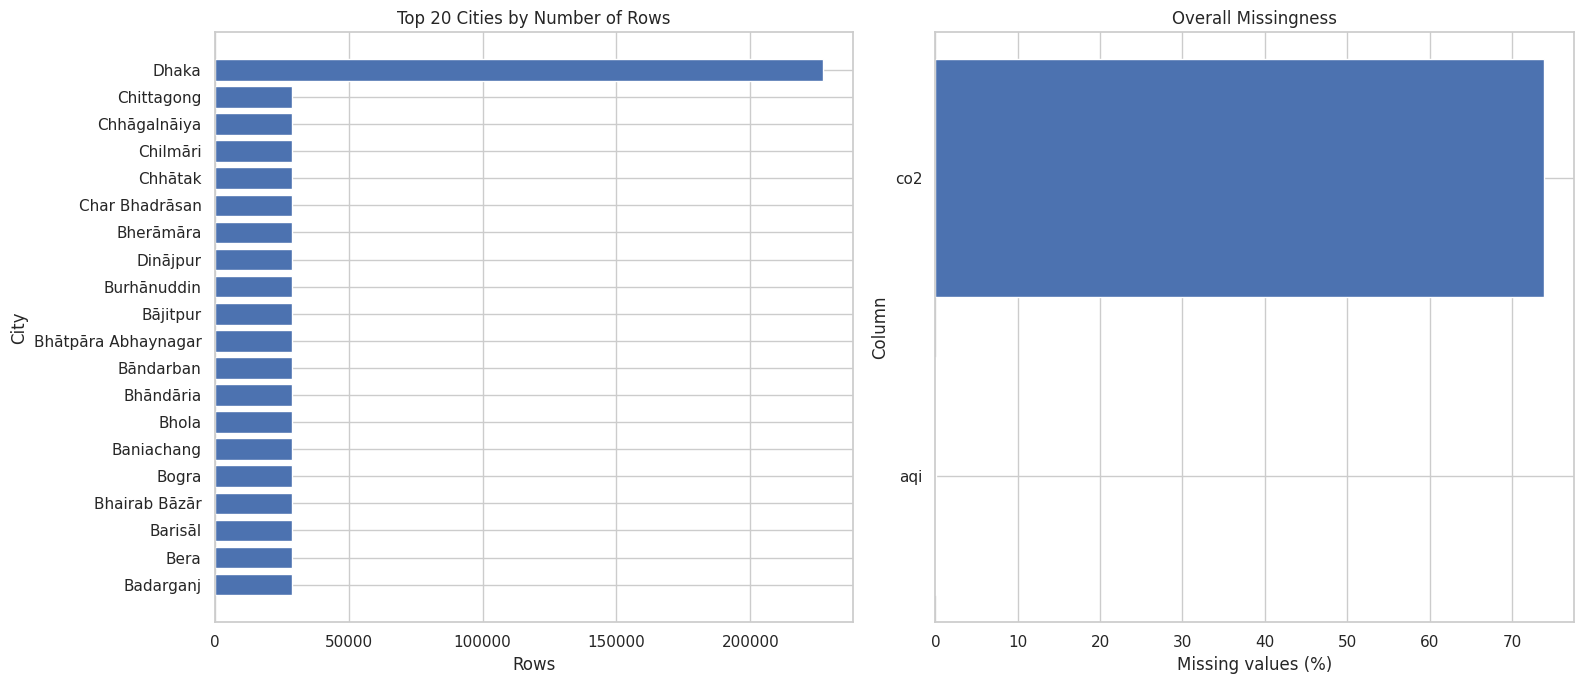

In [41]:
top_20_coverage = coverage.head(20).sort_values("row_count")
top_missing = missingness.loc[missingness["missing_percent"] > 0].head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].barh(top_20_coverage["city"], top_20_coverage["row_count"])
axes[0].set_title("Top 20 Cities by Number of Rows")
axes[0].set_xlabel("Rows")
axes[0].set_ylabel("City")

axes[1].barh(top_missing.index[::-1], top_missing["missing_percent"][::-1])
axes[1].set_title("Overall Missingness")
axes[1].set_xlabel("Missing values (%)")
axes[1].set_ylabel("Column")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_coverage_and_missingness.png", dpi=300, bbox_inches="tight")
plt.show()

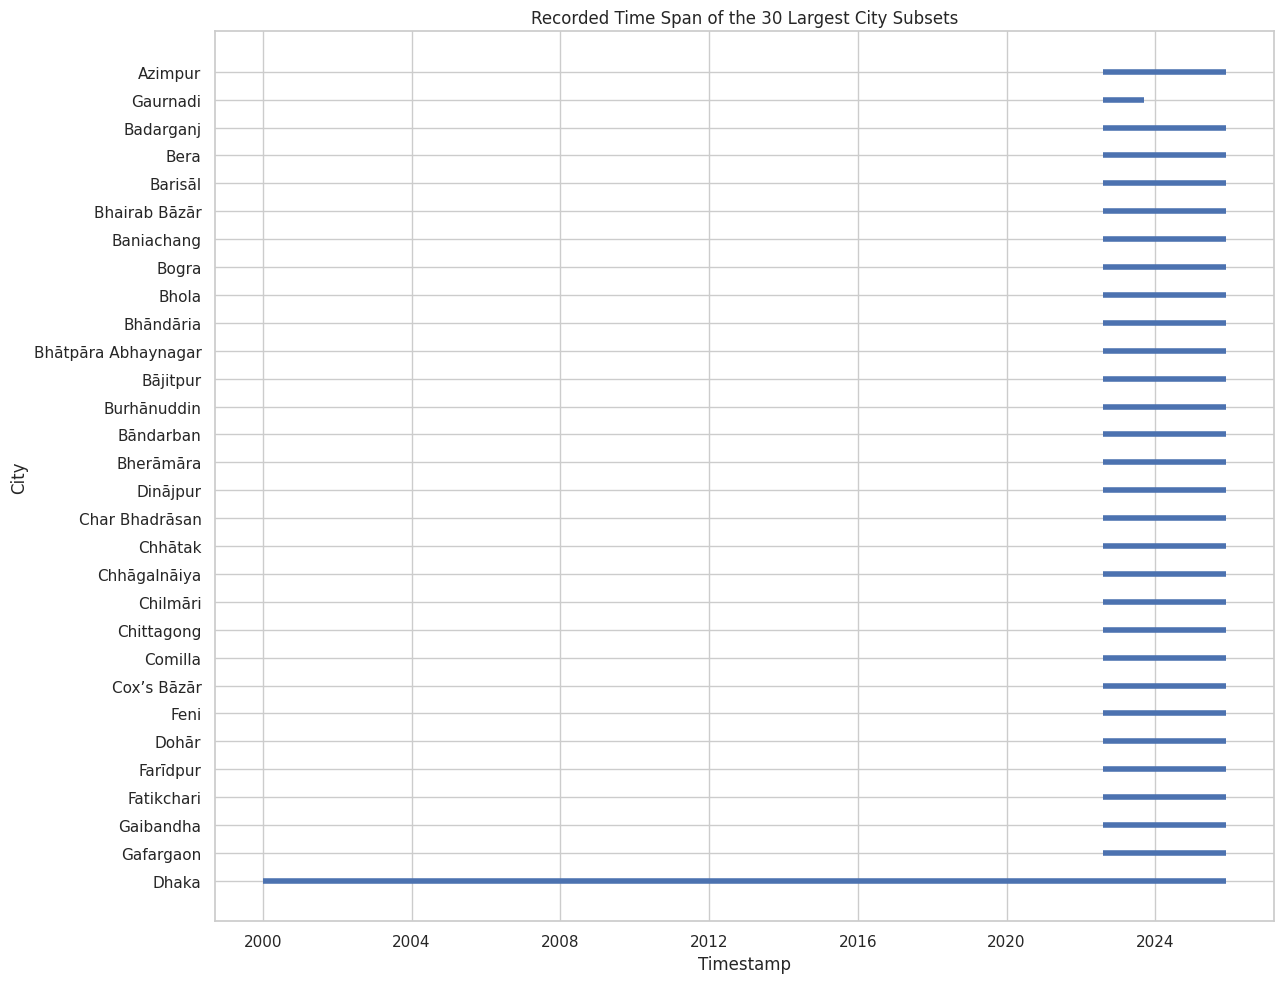

In [42]:
timeline = coverage.head(30).sort_values("first_timestamp").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(13, 10))

for index, row in timeline.iterrows():
    ax.hlines(index, row["first_timestamp"], row["last_timestamp"], linewidth=4)

ax.set_yticks(range(len(timeline)))
ax.set_yticklabels(timeline["city"])
ax.set_title("Recorded Time Span of the 30 Largest City Subsets")
ax.set_xlabel("Timestamp")
ax.set_ylabel("City")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_city_coverage_timeline.png", dpi=300, bbox_inches="tight")
plt.show()

## 16. AQI Distribution and Pollutant Relationships

This section performs an initial exploratory analysis of the numeric air-quality variables.

A reproducible sample of up to 100,000 rows is used to keep the visualizations efficient.

The section produces:

- A histogram of hourly AQI values
- Reference lines for the AQI 101+ and AQI 151+ thresholds
- A Spearman correlation heatmap for AQI and the available pollutants

Spearman correlation is used because pollutant measurements and AQI may have nonlinear relationships and extreme values. These correlations are descriptive only and do not establish which variables will be selected for modeling.

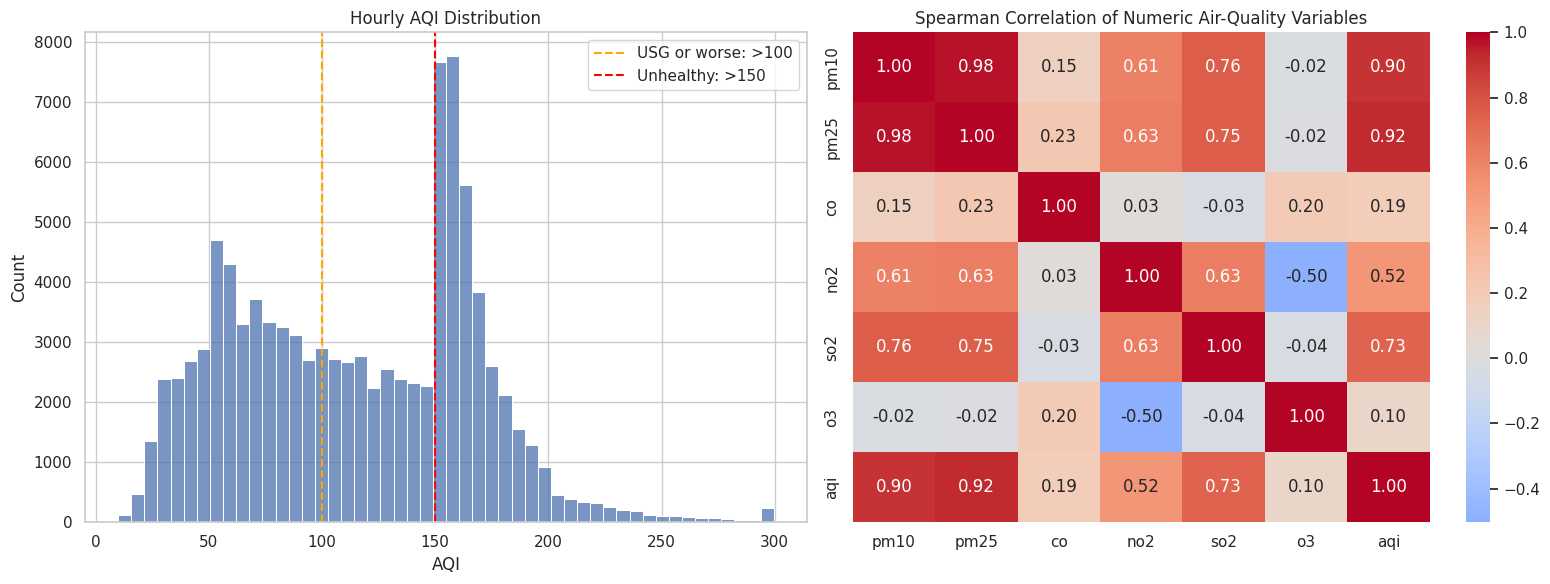

In [43]:
plot_columns = [
    column
    for column in ["pm10", "pm25", "co", "no2", "so2", "o3", "aqi"]
    if column in audit_valid.columns
]

sample_size = min(100_000, len(audit_valid))
eda_sample = audit_valid[plot_columns].sample(sample_size, random_state=RANDOM_SEED)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(eda_sample["aqi"].dropna(), bins=50, ax=axes[0])
axes[0].axvline(100, color="orange", linestyle="--", label="USG or worse: >100")
axes[0].axvline(150, color="red", linestyle="--", label="Unhealthy: >150")
axes[0].set_title("Hourly AQI Distribution")
axes[0].set_xlabel("AQI")
axes[0].legend()

correlation = eda_sample.corr(method="spearman")
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[1])
axes[1].set_title("Spearman Correlation of Numeric Air-Quality Variables")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_aqi_distribution_and_correlation.png", dpi=300, bbox_inches="tight")
plt.show()

## 17. Provisional Daily AQI Aggregation

This section converts hourly observations into provisional city-day summaries for the audit.

It calculates the daily maximum, mean, and median of the provided hourly AQI values. A day is considered usable when it contains at least 18 unique recorded hours and at least 18 valid AQI observations.

The final class-balance comparison is performed later using only the common study period of the selected cities.

In [44]:
daily_diagnostic = (
    audit_valid.groupby(["city", "date"])
    .agg(
        daily_aqi_max=("aqi", "max"),
        daily_aqi_mean=("aqi", "mean"),
        daily_aqi_median=("aqi", "median"),
        unique_hours=("hour", "nunique"),
        valid_aqi_hours=("aqi", "count"),
    )
    .reset_index()
)

usable_daily_diagnostic = daily_diagnostic.loc[
    daily_diagnostic["unique_hours"].ge(MIN_HOURS_PER_DAY)
    & daily_diagnostic["valid_aqi_hours"].ge(MIN_HOURS_PER_DAY)
].copy()

print("All city-days:", len(daily_diagnostic))
print("Usable city-days:", len(usable_daily_diagnostic))
print("Excluded city-days:", len(daily_diagnostic) - len(usable_daily_diagnostic))

display(usable_daily_diagnostic.head())

usable_daily_diagnostic.to_csv(
    AUDIT_DIR / "provisional_daily_aqi_diagnostic.csv",
    index=False,
)

All city-days: 43690
Usable city-days: 43660
Excluded city-days: 30


,city,date,daily_aqi_max,daily_aqi_mean,daily_aqi_median,unique_hours,valid_aqi_hours
0,Azimpur,2022-08-05,52.0,51.666667,52.0,24,24
1,Azimpur,2022-08-06,54.0,52.750000,53.0,24,24
2,Azimpur,2022-08-07,53.0,50.125000,50.0,24,24
3,Azimpur,2022-08-08,48.0,40.791667,40.0,24,24
4,Azimpur,2022-08-09,34.0,31.083333,31.0,24,24


## 18. Final City Selection and Common Study Period

Coverage alone cannot distinguish between most eligible cities because they have identical dates and hourly completeness.

Therefore, five cities are selected using two pre-declared criteria:

1. Complete overlap with Dhaka during the common study period
2. Geographic diversity across Bangladesh

The selected cities are:

- Dhaka — central megacity and training domain
- Dinajpur — northern Bangladesh
- Bheramara — western Bangladesh
- Bhola — southern river and coastal region
- Cox's Bazar — southeastern coastal region

Cities are not selected according to model performance or target prevalence. This avoids choosing locations that make the final results appear artificially better.

In [45]:
recommended_cities = [
    "Dhaka",
    "Dinājpur",
    "Bherāmāra",
    "Bhola",
    "Cox’s Bāzār",
]

selection_reasons = {
    "Dhaka": "Central megacity and model-training domain",
    "Dinājpur": "Northern geographic region",
    "Bherāmāra": "Western geographic region",
    "Bhola": "Southern river and coastal region",
    "Cox’s Bāzār": "Southeastern coastal region",
}

missing_selected_cities = [
    city for city in recommended_cities
    if city not in set(audit_valid["city"])
]

if missing_selected_cities:
    raise ValueError(f"Selected cities not found: {missing_selected_cities}")

city_coordinates = (
    audit_valid.groupby("city")
    .agg(
        latitude=("latitude", "first"),
        longitude=("longitude", "first"),
    )
    .reset_index()
)

final_city_table = coverage.loc[
    coverage["city"].isin(recommended_cities)
].copy()

final_city_table = final_city_table.merge(
    city_coordinates,
    on="city",
    how="left",
)

final_city_table["selection_reason"] = final_city_table["city"].map(selection_reasons)
final_city_table["selection_order"] = final_city_table["city"].map(
    {city: index for index, city in enumerate(recommended_cities)}
)

final_city_table = final_city_table.sort_values("selection_order")

assert len(final_city_table) == len(recommended_cities)
assert final_city_table["observed_days"].ge(365).all()
assert final_city_table["median_unique_hours_per_day"].ge(18).all()
assert final_city_table["aqi_non_missing_percent"].ge(80).all()

display(
    final_city_table[[
        "city",
        "latitude",
        "longitude",
        "observed_days",
        "median_unique_hours_per_day",
        "aqi_non_missing_percent",
        "selection_reason",
    ]]
)

final_city_table.to_csv(AUDIT_DIR / "final_selected_cities.csv", index=False)

,city,latitude,longitude,observed_days,median_unique_hours_per_day,aqi_non_missing_percent,selection_reason
0,Dhaka,23.71040,90.40744,9459,24.0,99.989428,Central megacity and model-training domain
3,Dinājpur,25.62745,88.63779,1208,24.0,99.917219,Northern geographic region
2,Bherāmāra,24.02452,88.99234,1208,24.0,99.917219,Western geographic region
1,Bhola,22.68759,90.64403,1208,24.0,99.917219,Southern river and coastal region
4,Cox’s Bāzār,21.43973,92.00955,1208,24.0,99.917219,Southeastern coastal region


In [46]:
usable_date_sets = {
    city: set(group["date"])
    for city, group in usable_daily_diagnostic.groupby("city")
}

common_dates = usable_date_sets[recommended_cities[0]].copy()

for city in recommended_cities[1:]:
    common_dates &= usable_date_sets[city]

if not common_dates:
    raise ValueError("The selected cities do not share any usable dates.")

COMMON_START = min(common_dates)
COMMON_END = max(common_dates)

print("Final selected cities:", recommended_cities)
print("Common usable dates:", len(common_dates))
print("Common start date:", COMMON_START)
print("Common end date:", COMMON_END)

assert len(common_dates) >= 365

Final selected cities: ['Dhaka', 'Dinājpur', 'Bherāmāra', 'Bhola', 'Cox’s Bāzār']
Common usable dates: 1207
Common start date: 2022-08-05 00:00:00
Common end date: 2025-11-23 00:00:00


## 19. Common-Period Target and Aggregation Comparison

Class balance must be calculated using the same dates for every city. Dhaka's older observations are therefore excluded from this comparison.

This section compares three possible daily summaries:

- Maximum hourly AQI
- Mean hourly AQI
- Median hourly AQI

The main project definition uses the daily maximum because it represents whether the city reached an unhealthy AQI level at any time during the day. Mean and median results are retained as sensitivity diagnostics.

The final positive class is:

`next day's daily maximum AQI > 150`

In [47]:
common_daily = usable_daily_diagnostic.loc[
    usable_daily_diagnostic["city"].isin(recommended_cities)
    & usable_daily_diagnostic["date"].isin(common_dates)
].copy()

common_daily["unhealthy_max_151_plus"] = common_daily["daily_aqi_max"].gt(150)
common_daily["unhealthy_mean_151_plus"] = common_daily["daily_aqi_mean"].gt(150)
common_daily["unhealthy_median_151_plus"] = common_daily["daily_aqi_median"].gt(150)
common_daily["usg_or_worse_max_101_plus"] = common_daily["daily_aqi_max"].gt(100)

aggregation_balance = (
    common_daily.groupby("city")
    .agg(
        usable_days=("date", "nunique"),
        unhealthy_max_days=("unhealthy_max_151_plus", "sum"),
        unhealthy_max_rate=("unhealthy_max_151_plus", "mean"),
        unhealthy_mean_days=("unhealthy_mean_151_plus", "sum"),
        unhealthy_mean_rate=("unhealthy_mean_151_plus", "mean"),
        unhealthy_median_days=("unhealthy_median_151_plus", "sum"),
        unhealthy_median_rate=("unhealthy_median_151_plus", "mean"),
        usg_or_worse_max_rate=("usg_or_worse_max_101_plus", "mean"),
    )
    .reset_index()
)

rate_columns = [
    "unhealthy_max_rate",
    "unhealthy_mean_rate",
    "unhealthy_median_rate",
    "usg_or_worse_max_rate",
]

aggregation_balance[rate_columns] *= 100
aggregation_balance[rate_columns] = aggregation_balance[rate_columns].round(2)

aggregation_balance["selection_order"] = aggregation_balance["city"].map(
    {city: index for index, city in enumerate(recommended_cities)}
)

aggregation_balance = (
    aggregation_balance
    .sort_values("selection_order")
    .drop(columns="selection_order")
)

display(aggregation_balance)

common_daily.to_csv(AUDIT_DIR / "common_period_daily_aqi.csv", index=False)
aggregation_balance.to_csv(AUDIT_DIR / "common_period_target_balance.csv", index=False)

,city,usable_days,unhealthy_max_days,unhealthy_max_rate,unhealthy_mean_days,unhealthy_mean_rate,unhealthy_median_days,unhealthy_median_rate,usg_or_worse_max_rate
3,Dhaka,1207,563,46.64,435,36.04,452,37.45,65.29
4,Dinājpur,1207,540,44.74,395,32.73,410,33.97,73.65
0,Bherāmāra,1207,660,54.68,511,42.34,519,43.00,73.32
1,Bhola,1207,339,28.09,238,19.72,251,20.80,47.97
2,Cox’s Bāzār,1207,297,24.61,109,9.03,108,8.95,46.56


## 20. Diagnostic Comparison of Recommended Cities

This section visualizes the cities recommended by the coverage audit.

It produces:

- A time-series plot of provisional daily maximum AQI
- A comparison of the percentage of usable days with AQI greater than 150

These figures help reveal differences in temporal coverage, AQI behaviour, and class balance. They are exploratory diagnostics and should not be interpreted as final modeling results.

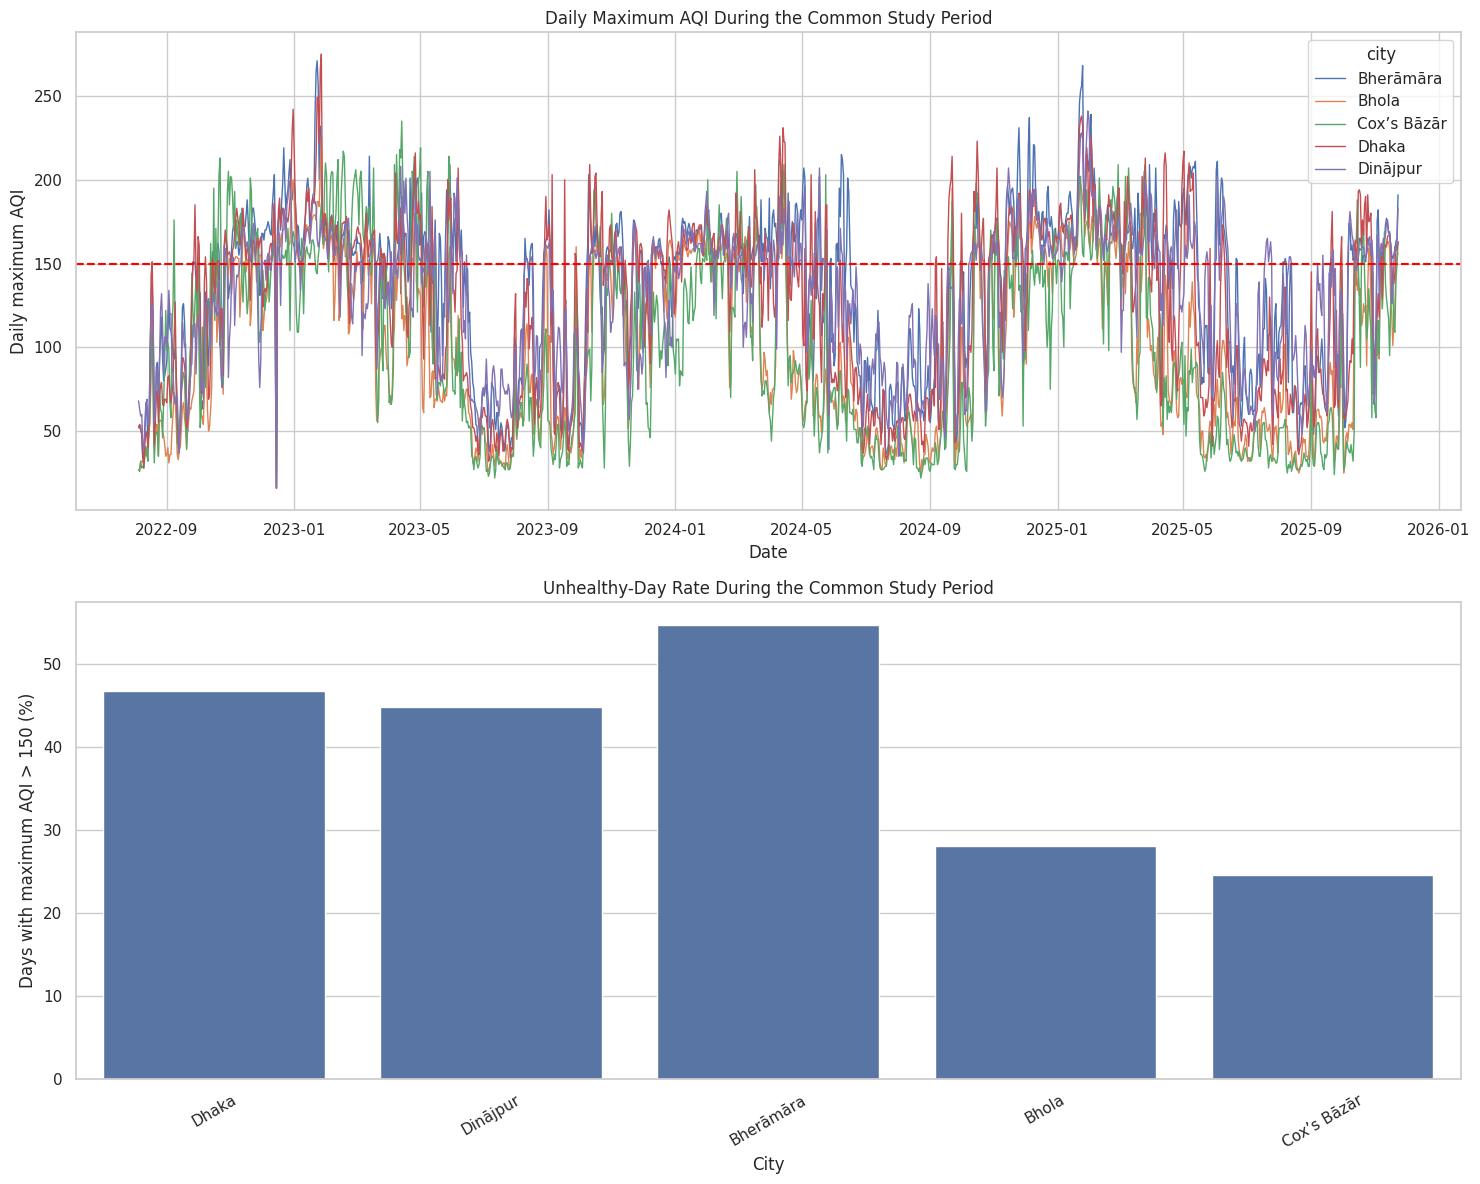

In [48]:
fig, axes = plt.subplots(2, 1, figsize=(15, 12))

sns.lineplot(
    data=common_daily,
    x="date",
    y="daily_aqi_max",
    hue="city",
    linewidth=1,
    ax=axes[0],
)

axes[0].axhline(150, color="red", linestyle="--", label="Unhealthy threshold")
axes[0].set_title("Daily Maximum AQI During the Common Study Period")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Daily maximum AQI")

sns.barplot(
    data=aggregation_balance,
    x="city",
    y="unhealthy_max_rate",
    ax=axes[1],
)

axes[1].set_title("Unhealthy-Day Rate During the Common Study Period")
axes[1].set_xlabel("City")
axes[1].set_ylabel("Days with maximum AQI > 150 (%)")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "04_final_city_common_period_diagnostics.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## 21. Audit Summary and Output Files

This section combines the main audit findings into a structured summary.

The saved `audit_summary.json` records:

- Source-file details and checksum
- Dataset dimensions
- Number of cities
- Overall timestamp range
- Duplicate counts
- Distance from Excel's row limit
- Equivalent coverage per city
- Recommended cities
- Common usable period
- Seasonality decision
- Proposed daily AQI and target definitions
- Timestamp interpretation warning

The final code cell lists every saved audit table and figure so that the team can confirm that all expected outputs were created successfully.

In [50]:
selected_seasonality = seasonality_summary.loc[
    seasonality_summary["city"].isin(recommended_cities)
]

seasonality_supported_for_all = bool(
    len(selected_seasonality) == len(recommended_cities)
    and selected_seasonality["seasonality_supported"].all()
)

common_unhealthy_rates = {
    row["city"]: float(row["unhealthy_max_rate"])
    for _, row in aggregation_balance.iterrows()
}

audit_summary = {
    "source_file": RAW_FILE.name,
    "file_size_mb": round(file_size_mb, 2),
    "sha256": file_checksum,
    "source_rows": int(len(df_raw)),
    "source_columns": int(df_raw.shape[1]),
    "cities_in_main_file": int(audit["city"].nunique()),
    "cities_in_metadata_file": int(cities_metadata["metadata_city"].nunique()),
    "metadata_cities_missing_from_main": int(len(metadata_only_cities)),
    "minimum_timestamp": str(audit_valid["timestamp"].min()),
    "maximum_timestamp": str(audit_valid["timestamp"].max()),
    "exact_duplicate_rows": exact_duplicate_rows,
    "duplicate_city_timestamp_pairs": duplicate_city_timestamps,
    "rows_below_excel_limit": int(excel_rows_remaining),
    "truncation_conclusion": (
        "Strong evidence of Excel truncation: the main file contains only "
        "30 cities, ends 24 rows below Excel's limit, and the final city "
        "contains a partial block."
    ),
    "negative_no2_rows": int(audit["no2"].lt(0).sum()),
    "negative_o3_rows": int(audit["o3"].lt(0).sum()),
    "selected_cities": recommended_cities,
    "selection_method": "Complete common coverage and geographic diversity",
    "common_usable_days": int(len(common_dates)),
    "common_first_date": str(COMMON_START),
    "common_last_date": str(COMMON_END),
    "common_period_unhealthy_rates": common_unhealthy_rates,
    "seasonality_supported_for_selected_cities": seasonality_supported_for_all,
    "seasonality_decision": "Retain as optional descriptive EDA only.",
    "daily_aqi_aggregation": "Maximum provided hourly AQI",
    "main_target": "Next calendar day's daily maximum AQI > 150",
    "optional_sensitivity_target": "Next calendar day's daily maximum AQI > 100",
    "excluded_predictor": "CO2",
    "timestamp_decision": (
        "Use the recorded clock times without shifting the day boundary. "
        "The source timestamps contain no timezone offset."
    ),
}

with (AUDIT_DIR / "audit_summary.json").open("w", encoding="utf-8") as file:
    json.dump(audit_summary, file, indent=2, ensure_ascii=False)

print(json.dumps(audit_summary, indent=2, ensure_ascii=False))

{
  "source_file": "AQI Bangladesh.csv",
  "file_size_mb": 93.75,
  "sha256": "8760175fc048eea4180b828fd60d10cb799a73a5144a7e4aca19ddbaf8dbdd62",
  "source_rows": 1048551,
  "source_columns": 13,
  "cities_in_main_file": 30,
  "cities_in_metadata_file": 103,
  "metadata_cities_missing_from_main": 73,
  "minimum_timestamp": "2000-01-01 00:00:00+00:00",
  "maximum_timestamp": "2025-11-23 23:00:00+00:00",
  "exact_duplicate_rows": 0,
  "duplicate_city_timestamp_pairs": 0,
  "rows_below_excel_limit": 24,
  "truncation_conclusion": "Strong evidence of Excel truncation: the main file contains only 30 cities, ends 24 rows below Excel's limit, and the final city contains a partial block.",
  "negative_no2_rows": 1,
  "negative_o3_rows": 11,
  "selected_cities": [
    "Dhaka",
    "Dinājpur",
    "Bherāmāra",
    "Bhola",
    "Cox’s Bāzār"
  ],
  "selection_method": "Complete common coverage and geographic diversity",
  "common_usable_days": 1207,
  "common_first_date": "2022-08-05 00:00:00",
 

In [51]:
print("Saved audit files:")

for file in sorted(AUDIT_DIR.iterdir()):
    print("-", file.name)

print("\nSaved figures:")

for file in sorted(FIGURES_DIR.iterdir()):
    print("-", file.name)

Saved audit files:
- audit_summary.json
- city_coverage_summary.csv
- city_gap_summary.csv
- city_selection_candidates.csv
- common_period_daily_aqi.csv
- common_period_target_balance.csv
- final_selected_cities.csv
- invalid_pollutant_rows.csv
- metadata_cities_missing_from_aqi_data.csv
- metadata_city_comparison.csv
- missingness_by_city.csv
- monthly_coverage.csv
- overall_missingness.csv
- provisional_daily_aqi_diagnostic.csv
- provisional_threshold_summary.csv
- quality_by_city.csv
- seasonality_summary.csv
- source_city_blocks.csv
- unexpected_cities_in_aqi_data.csv

Saved figures:
- 01_coverage_and_missingness.png
- 02_city_coverage_timeline.png
- 03_aqi_distribution_and_correlation.png
- 04_final_city_common_period_diagnostics.png
- 04_recommended_city_diagnostics.png


## 22. Audit-Gate Decision

### Verified dataset facts

- The source contains **1,048,551 rows and 13 original columns**.
- The main CSV contains **30 cities**, although the publisher describes 103.
- The recorded timestamp range is **1 January 2000 to 23 November 2025**.
- Dhaka contains the long 2000–2025 history.
- Most non-Dhaka cities begin in August 2022.
- The file ends only **24 rows below Excel's maximum row capacity**.
- The final city block is incomplete.
- These findings provide strong evidence that the published CSV is an Excel-truncated export.
- The faculty has allowed the project to proceed as long as this limitation is documented.

### Selected scope

The final selected cities are:

1. **Dhaka** — central megacity and training domain
2. **Dinajpur** — northern region
3. **Bheramara** — western region
4. **Bhola** — southern river and coastal region
5. **Cox's Bazar** — southeastern coastal region

The cities were selected using complete common coverage and geographic diversity, not model performance.

The common usable study period is:

- **Start:** 5 August 2022
- **End:** 23 November 2025
- **Common usable dates:** 1,207

Only this common period will be used for the main cross-city experiment.

### Data-quality decisions

- No exact duplicate rows were found.
- No duplicate city–timestamp combinations were found.
- No timestamp gaps were found in the selected city series.
- One negative NO2 value and eleven negative O3 values will be converted to missing values.
- CO2 will be removed because it is not part of the target AQI methodology and is approximately 74% missing.
- The small number of missing AQI observations will not be imputed for target construction.
- A city-day must contain at least 18 valid hourly AQI observations.
- Source timestamps contain no timezone information, so recorded clock times will be used without shifting the day boundary.

### Seasonality decision

- Dhaka contains many complete years.
- Each selected non-Dhaka city contains two complete usable years.
- Seasonal analysis is technically possible for the common period.
- It will remain optional descriptive EDA and will not be restored as a primary research question.

### Target decision

- Daily AQI is defined as the maximum provided hourly AQI during that calendar day.
- The main positive class is **next day's daily maximum AQI > 150**.
- AQI values from 101–150 remain negative in the main target.
- A separate AQI > 100 sensitivity analysis may be reported if useful.
- Every modeling feature must come from the current day or earlier.

### Audit gate

- [x] Actual coverage verified
- [x] Main dataset compared with city metadata
- [x] Possible truncation investigated and documented
- [x] Faculty permission to proceed recorded
- [x] Five cities approved
- [x] Common study period approved
- [x] Seasonality decision recorded
- [x] Daily AQI aggregation approved
- [x] Target threshold approved
- [x] Invalid-value decisions recorded
- [x] CO2 exclusion confirmed

**Notebook 01 has passed its audit gate. Notebook 02 may begin after the notebook is rerun successfully and the final outputs are saved.**